# Temperature Causal Analysis

This notebook studies the causal impact of `temperature` on three outcomes: `Agreement (µ)`, `Consistency (µ)`, and `Error Rate (µ)` using the grouped results in `output/result_without_rep_id`.

## Design choices

- Primary treatment: `high_temperature = 1[temperature >= 1.5]`, compared against `low_temperature = 1[temperature < 1.5]`.
- Primary estimand: ATE of moving from the low-temperature regime to the high-temperature regime.
- Adjustment set / confounders: `question_id`, `judge_type`, `prompt_variant`, `model`.
- Moderators: `judge_type`, `prompt_variant`, `model`.
- Main estimator: cross-fitted AIPW with LightGBM nuisance models.
- Feature attribution: DAG-aware grouped SHAP on nuisance models.
- Robustness: placebo permutation test, approximate E-value, SHAP stability via bootstrap.

In [25]:
from __future__ import annotations

from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from graphviz import Digraph
from IPython.display import Markdown, display
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.model_selection import KFold

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(42)

DATA_DIR = Path("output/result_without_rep_id")
FIG_DIR = Path("output/causal_analysis")
FIG_DIR.mkdir(parents=True, exist_ok=True)

METRIC_COLUMNS = ["Agreement (µ)", "Consistency (µ)", "Error Rate (µ)"]
TREATMENT_SOURCE = "temperature"
TREATMENT_COL = "high_temperature"
TREATMENT_LABEL = "High temperature (>= 1.5) vs Low temperature (< 1.5)"
COVARIATE_COLUMNS = ["question_id", "judge_type", "prompt_variant", "model"]
MODERATOR_COLUMNS = ["judge_type", "prompt_variant", "model"]

data_paths = {
    path.stem.replace("metrics_by_question_judge_prompt_temp_", ""): path
    for path in sorted(DATA_DIR.glob("metrics_by_question_judge_prompt_temp_*.jsonl"))
}
MODEL_NAMES = list(data_paths)

if not MODEL_NAMES:
    raise FileNotFoundError(f"No model files found under {DATA_DIR}")

dfs = []
for model_name, path in data_paths.items():
    df = pd.read_json(path, lines=True)
    df["model"] = model_name
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)
combined_df[TREATMENT_SOURCE] = pd.to_numeric(combined_df[TREATMENT_SOURCE], errors="coerce")
combined_df[METRIC_COLUMNS] = combined_df[METRIC_COLUMNS].apply(pd.to_numeric, errors="coerce")
combined_df["question_id"] = combined_df["question_id"].astype(str)
combined_df[TREATMENT_COL] = (combined_df[TREATMENT_SOURCE] >= 1.5).astype(int)
combined_df["temperature_bucket"] = pd.Categorical(
    np.where(combined_df[TREATMENT_COL].eq(1), "high (>=1.5)", "low (<1.5)"),
    categories=["low (<1.5)", "high (>=1.5)"],
    ordered=True,
)

for col in COVARIATE_COLUMNS:
    combined_df[col] = combined_df[col].astype("category")

ANALYSIS_COLUMNS = [TREATMENT_SOURCE, TREATMENT_COL] + COVARIATE_COLUMNS + METRIC_COLUMNS
COLUMN_MAP = pd.DataFrame(
    [
        {"Role": "Treatment", "Variable": TREATMENT_SOURCE, "Description": "Sampling temperature of the judge model."},
        {"Role": "Binary treatment", "Variable": TREATMENT_COL, "Description": TREATMENT_LABEL},
        {"Role": "Outcome", "Variable": "Agreement (µ)", "Description": "Average agreement within each grouped unit."},
        {"Role": "Outcome", "Variable": "Consistency (µ)", "Description": "Average consistency within each grouped unit."},
        {"Role": "Outcome", "Variable": "Error Rate (µ)", "Description": "Average parse / format error rate within each grouped unit."},
        {"Role": "Confounder / FE", "Variable": "question_id", "Description": "Question-level fixed effect proxy."},
        {"Role": "Confounder / Moderator", "Variable": "judge_type", "Description": "Pairwise / single-answer / reference-guided judgment mode."},
        {"Role": "Confounder / Moderator", "Variable": "prompt_variant", "Description": "Prompt strategy such as baseline or chain-of-thought."},
        {"Role": "Confounder / Moderator", "Variable": "model", "Description": "Judge model identity."},
    ]
)


def make_lgbm_regressor(random_state: int = 42) -> LGBMRegressor:
    return LGBMRegressor(
        n_estimators=250,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
    )


def make_lgbm_classifier(random_state: int = 42) -> LGBMClassifier:
    return LGBMClassifier(
        n_estimators=250,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
    )


def standardized_mean_difference_binary(x: pd.Series, t: pd.Series) -> float:
    x = pd.to_numeric(x, errors="coerce").fillna(0.0)
    t = pd.to_numeric(t, errors="coerce").fillna(0).astype(int)
    treated = x[t.eq(1)]
    control = x[t.eq(0)]
    if len(treated) == 0 or len(control) == 0:
        return np.nan
    m1 = float(treated.mean())
    m0 = float(control.mean())
    v1 = float(treated.var(ddof=1)) if len(treated) > 1 else 0.0
    v0 = float(control.var(ddof=1)) if len(control) > 1 else 0.0
    pooled = math.sqrt(max((v1 + v0) / 2.0, 1e-12))
    return abs(m1 - m0) / pooled if pooled > 0 else 0.0


def _feature_family(name: str) -> str:
    for family in COVARIATE_COLUMNS:
        if name == family or name.startswith(f"{family}_"):
            return family
    return "other"


def compute_balance_table(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    dummies = pd.get_dummies(df[COVARIATE_COLUMNS], drop_first=False, dtype=float)
    treat = df[TREATMENT_COL].astype(int)
    detail_rows = []
    for col in dummies.columns:
        detail_rows.append(
            {
                "feature": col,
                "family": _feature_family(col),
                "abs_smd": standardized_mean_difference_binary(dummies[col], treat),
            }
        )
    balance_detail = pd.DataFrame(detail_rows).sort_values("abs_smd", ascending=False).reset_index(drop=True)
    balance_summary = (
        balance_detail.groupby("family", as_index=False)["abs_smd"]
        .agg(["mean", "max", "median"])
        .reset_index()
        .rename(columns={"mean": "mean_abs_smd", "max": "max_abs_smd", "median": "median_abs_smd"})
        .sort_values("max_abs_smd", ascending=False)
        .reset_index(drop=True)
    )
    return balance_summary, balance_detail


def build_dag() -> Digraph:
    dag = Digraph()
    dag.attr(rankdir="LR")
    dag.node("Q", "question_id", shape="box")
    dag.node("J", "judge_type", shape="box")
    dag.node("P", "prompt_variant", shape="box")
    dag.node("M", "model", shape="box")
    dag.node("T", "temperature", shape="ellipse", style="filled", fillcolor="lightblue")
    dag.node("A", "Agreement (µ)", shape="ellipse")
    dag.node("C", "Consistency (µ)", shape="ellipse")
    dag.node("E", "Error Rate (µ)", shape="ellipse")
    dag.node("U", "latent prompt / parsing complexity", shape="diamond", style="dashed")

    for parent in ["Q", "J", "P", "M"]:
        dag.edge(parent, "T")
        dag.edge(parent, "A")
        dag.edge(parent, "C")
        dag.edge(parent, "E")

    dag.edge("T", "A")
    dag.edge("T", "C")
    dag.edge("T", "E")
    dag.edge("U", "A", style="dashed")
    dag.edge("U", "C", style="dashed")
    dag.edge("U", "E", style="dashed")
    return dag


def cross_fitted_aipw(
    df: pd.DataFrame,
    outcome_col: str,
    treatment_col: str = TREATMENT_COL,
    covariate_cols: list[str] = COVARIATE_COLUMNS,
    n_splits: int = 3,
    random_state: int = 42,
    n_estimators: int = 250,
    trim: float = 0.025,
    return_fold_models: bool = False,
    display_progress: bool = False,
    progress_prefix: str = "",
) -> dict:
    work = df[covariate_cols + [treatment_col, outcome_col]].dropna().copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[outcome_col]).reset_index(drop=True)

    if work[treatment_col].nunique() < 2:
        raise ValueError(f"{outcome_col}: treatment has only one level after filtering.")

    W = work[covariate_cols].copy()
    T = work[treatment_col].astype(int).to_numpy()
    Y = work[outcome_col].to_numpy()

    mu0_hat = np.zeros(len(work), dtype=float)
    mu1_hat = np.zeros(len(work), dtype=float)
    e_hat = np.zeros(len(work), dtype=float)
    fold_models = []

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for fold_id, (train_idx, test_idx) in enumerate(kf.split(W), start=1):
        if display_progress:
            print(f"{progress_prefix}{outcome_col}: fitting fold {fold_id}/{n_splits}")

        W_train = W.iloc[train_idx].copy()
        W_test = W.iloc[test_idx].copy()
        T_train = T[train_idx]
        Y_train = Y[train_idx]

        prop_model = make_lgbm_classifier(random_state + fold_id)
        prop_model.set_params(n_estimators=n_estimators)
        prop_model.fit(W_train, T_train)
        e_hat[test_idx] = prop_model.predict_proba(W_test)[:, 1]

        mu0_model = make_lgbm_regressor(random_state + 100 + fold_id)
        mu1_model = make_lgbm_regressor(random_state + 200 + fold_id)
        mu0_model.set_params(n_estimators=n_estimators)
        mu1_model.set_params(n_estimators=n_estimators)

        mu0_model.fit(W_train.loc[T_train == 0], Y_train[T_train == 0])
        mu1_model.fit(W_train.loc[T_train == 1], Y_train[T_train == 1])

        mu0_hat[test_idx] = mu0_model.predict(W_test)
        mu1_hat[test_idx] = mu1_model.predict(W_test)

        fold_models.append({
            "propensity_model": prop_model,
            "mu0_model": mu0_model,
            "mu1_model": mu1_model,
        })

    e_hat = np.clip(e_hat, trim, 1.0 - trim)
    pseudo_effect = mu1_hat - mu0_hat + T * (Y - mu1_hat) / e_hat - (1 - T) * (Y - mu0_hat) / (1 - e_hat)
    ate = float(np.mean(pseudo_effect))
    se = float(np.std(pseudo_effect, ddof=1) / np.sqrt(len(pseudo_effect)))
    ci_low = ate - 1.96 * se
    ci_high = ate + 1.96 * se

    result = {
        "Outcome": outcome_col,
        "N": int(len(work)),
        "Outcome mean (treated)": float(work.loc[work[treatment_col] == 1, outcome_col].mean()),
        "Outcome mean (control)": float(work.loc[work[treatment_col] == 0, outcome_col].mean()),
        "ATE": ate,
        "SE": se,
        "CI Low": ci_low,
        "CI High": ci_high,
        "ATE (95% CI)": f"{ate:.4f} [{ci_low:.4f}, {ci_high:.4f}]",
        "pseudo_effect": pseudo_effect,
        "analysis_df": work,
        "e_hat": e_hat,
        "mu0_hat": mu0_hat,
        "mu1_hat": mu1_hat,
    }

    if return_fold_models:
        result["fold_models"] = fold_models

    return result


def subgroup_ate(df: pd.DataFrame, outcome_col: str, subgroup_col: str) -> pd.DataFrame:
    rows = []
    for level, group in df.groupby(subgroup_col, observed=True):
        if group[TREATMENT_COL].nunique() < 2:
            continue
        res = cross_fitted_aipw(
            group,
            outcome_col=outcome_col,
            n_splits=2,
            random_state=123,
            n_estimators=150,
        )
        rows.append(
            {
                "Outcome": outcome_col,
                "Moderator": subgroup_col,
                "Level": str(level),
                "N": res["N"],
                "ATE": res["ATE"],
                "CI Low": res["CI Low"],
                "CI High": res["CI High"],
                "ATE (95% CI)": res["ATE (95% CI)"],
            }
        )
    return pd.DataFrame(rows).sort_values("ATE").reset_index(drop=True)


def fit_global_nuisance_models(df: pd.DataFrame, outcome_col: str) -> tuple[pd.DataFrame, LGBMRegressor, LGBMClassifier]:
    work = df[[TREATMENT_COL] + COVARIATE_COLUMNS + [outcome_col]].dropna().copy()
    outcome_model = make_lgbm_regressor(777)
    propensity_model = make_lgbm_classifier(888)
    outcome_model.fit(work[[TREATMENT_COL] + COVARIATE_COLUMNS], work[outcome_col])
    propensity_model.fit(work[COVARIATE_COLUMNS], work[TREATMENT_COL].astype(int))
    return work, outcome_model, propensity_model


def grouped_shap_importance(
    model,
    data: pd.DataFrame,
    feature_groups: dict[str, str],
    max_rows: int = 3000,
    random_state: int = 42,
    title: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    sample = data.sample(min(len(data), max_rows), random_state=random_state).copy()
    explainer = shap.TreeExplainer(model)
    explanation = explainer(sample)
    shap_values = np.asarray(explanation.values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, -1]
    abs_shap = pd.DataFrame(np.abs(shap_values), columns=sample.columns)
    grouped = (
        pd.DataFrame(
            {
                "feature": sample.columns,
                "group": [feature_groups.get(col, col) for col in sample.columns],
                "mean_abs_shap": abs_shap.mean(axis=0).values,
            }
        )
        .groupby("group", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )
    if title is not None:
        grouped["title"] = title
    return grouped, sample


def placebo_permutation_test(
    df: pd.DataFrame,
    outcome_col: str,
    n_perm: int = 10,
    random_state: int = 42,
    progress_prefix: str = "",
) -> dict:
    rng = np.random.default_rng(random_state)
    observed = cross_fitted_aipw(
        df,
        outcome_col=outcome_col,
        n_splits=2,
        random_state=random_state,
        n_estimators=120,
        display_progress=False,
    )["ATE"]
    placebo_draws = []
    for perm_idx in range(n_perm):
        if progress_prefix:
            print(f"{progress_prefix}{outcome_col}: placebo permutation {perm_idx + 1}/{n_perm}")
        perm_df = df.copy()
        perm_df[TREATMENT_COL] = rng.permutation(perm_df[TREATMENT_COL].to_numpy())
        perm_ate = cross_fitted_aipw(
            perm_df,
            outcome_col=outcome_col,
            n_splits=2,
            random_state=random_state + perm_idx + 1,
            n_estimators=120,
            display_progress=False,
        )["ATE"]
        placebo_draws.append(perm_ate)
    placebo_draws = np.asarray(placebo_draws, dtype=float)
    p_value = (np.sum(np.abs(placebo_draws) >= abs(observed)) + 1) / (len(placebo_draws) + 1)
    return {
        "Outcome": outcome_col,
        "Observed ATE": float(observed),
        "Placebo mean": float(np.mean(placebo_draws)),
        "Placebo std": float(np.std(placebo_draws, ddof=1)),
        "Permutation p-value": float(p_value),
        "placebo_draws": placebo_draws,
    }


def approximate_e_value(y: pd.Series, ate: float) -> dict:
    y_clean = pd.to_numeric(y, errors="coerce").dropna()
    sd = float(y_clean.std(ddof=1)) if len(y_clean) > 1 else np.nan
    if not np.isfinite(sd) or sd == 0:
        return {"Cohen's d": np.nan, "Approx RR": np.nan, "E-value": np.nan}
    d_value = ate / sd
    rr_approx = math.exp(0.91 * abs(d_value))
    e_value = rr_approx + math.sqrt(rr_approx * (rr_approx - 1.0)) if rr_approx > 1.0 else 1.0
    return {
        "Cohen's d": float(d_value),
        "Approx RR": float(rr_approx),
        "E-value": float(e_value),
    }


def shap_stability(
    df: pd.DataFrame,
    outcome_col: str,
    feature_cols: list[str],
    feature_groups: dict[str, str],
    n_boot: int = 8,
    max_rows: int = 2500,
    random_state: int = 42,
    progress_prefix: str = "",
) -> pd.DataFrame:
    base = df[feature_cols + [outcome_col]].dropna().copy()
    frames = []
    for boot_idx in range(n_boot):
        if progress_prefix:
            print(f"{progress_prefix}{outcome_col}: SHAP bootstrap {boot_idx + 1}/{n_boot}")
        boot = base.sample(len(base), replace=True, random_state=random_state + boot_idx)
        model = make_lgbm_regressor(random_state + 1000 + boot_idx)
        model.set_params(n_estimators=150)
        model.fit(boot[feature_cols], boot[outcome_col])
        grouped, _ = grouped_shap_importance(
            model,
            boot[feature_cols],
            feature_groups=feature_groups,
            max_rows=max_rows,
            random_state=random_state + 2000 + boot_idx,
        )
        grouped["bootstrap"] = boot_idx
        grouped["Outcome"] = outcome_col
        frames.append(grouped)
    stability = pd.concat(frames, ignore_index=True)
    summary = (
        stability.groupby(["Outcome", "group"], as_index=False)["mean_abs_shap"]
        .agg(["mean", "std"])
        .reset_index()
        .rename(columns={"mean": "bootstrap_mean_abs_shap", "std": "bootstrap_std_abs_shap"})
        .sort_values(["Outcome", "bootstrap_mean_abs_shap"], ascending=[True, False])
        .reset_index(drop=True)
    )
    return summary


print(f"Loaded {len(combined_df):,} rows from {len(MODEL_NAMES)} model files.")
print("Models:", MODEL_NAMES)
print("Temperature support:", sorted(combined_df[TREATMENT_SOURCE].dropna().unique().tolist()))

Loaded 90,000 rows from 5 model files.
Models: ['Llama-3.1-8B-Instruct', 'Qwen3-30B-A3B-Instruct-2507', 'Qwen3-Next-80B-A3B-Instruct-FP8', 'Qwen3-Next-80B-A3B-Thinking-FP8', 'gemma-3-27b-it']
Temperature support: [0.01, 0.5, 1.0, 1.5, 2.0, 3.0]


,Role,Variable,Description
0,Treatment,temperature,Sampling temperature of the judge model.
1,Binary treatment,high_temperature,High temperature (>= 1.5) vs Low temperature (...
2,Outcome,Agreement (µ),Average agreement within each grouped unit.
3,Outcome,Consistency (µ),Average consistency within each grouped unit.
4,Outcome,Error Rate (µ),Average parse / format error rate within each ...
5,Confounder / FE,question_id,Question-level fixed effect proxy.
6,Confounder / Moderator,judge_type,Pairwise / single-answer / reference-guided ju...
7,Confounder / Moderator,prompt_variant,Prompt strategy such as baseline or chain-of-t...
8,Confounder / Moderator,model,Judge model identity.


,temperature,high_temperature,question_id,judge_type,prompt_variant,model,Agreement (µ),Consistency (µ),Error Rate (µ)
0,0.01,0,0,pairwise,baseline,Llama-3.1-8B-Instruct,1.000000,1.000000,0.0
1,0.50,0,0,pairwise,baseline,Llama-3.1-8B-Instruct,1.000000,1.000000,0.0
2,1.00,0,0,pairwise,baseline,Llama-3.1-8B-Instruct,0.900000,0.777778,0.0
3,1.50,1,0,pairwise,baseline,Llama-3.1-8B-Instruct,0.333333,0.000000,0.1
4,2.00,1,0,pairwise,baseline,Llama-3.1-8B-Instruct,0.000000,1.000000,0.1


Agreement (µ)                   Consistency (µ)                    \
                     mean     std  min  max            mean     std  min  max   
temperature                                                                     
0.01               0.5233  0.4784  0.0  1.0          0.7365  0.4072  0.0  1.0   
0.50               0.5203  0.4598  0.0  1.0          0.6886  0.4053  0.0  1.0   
1.00               0.5154  0.4433  0.0  1.0          0.6433  0.4061  0.0  1.0   
1.50               0.4909  0.4439  0.0  1.0          0.6382  0.4035  0.0  1.0   
2.00               0.4711  0.4508  0.0  1.0          0.6554  0.4052  0.0  1.0   
3.00               0.4445  0.4235  0.0  1.0          0.5876  0.3995  0.0  1.0   

            Error Rate (µ)                    
                      mean     std  min  max  
temperature                                   
0.01                0.2284  0.3970  0.0  1.0  
0.50                0.2317  0.3905  0.0  1.0  
1.00                0.2422  0.3866  0.0  1.0  
1.50                0.2768  0.4047  0.0  1.0  
2.00                0.3014  0.4006  0.0  1.0  
3.00                0.3563  0.3887  0.0  1.0

,rows
temperature_bucket,
low (<1.5),45000
high (>=1.5),45000


Balance summary by covariate family (absolute SMD):


,index,family,mean_abs_smd,max_abs_smd,median_abs_smd
0,0,judge_type,0.0,0.0,0.0
1,1,model,0.0,0.0,0.0
2,2,prompt_variant,0.0,0.0,0.0
3,3,question_id,0.0,0.0,0.0


Largest individual imbalances:


,feature,family,abs_smd
0,model_gemma-3-27b-it,model,0.0
1,question_id_0,question_id,0.0
2,question_id_1,question_id,0.0
3,question_id_10,question_id,0.0
4,question_id_100,question_id,0.0
5,question_id_101,question_id,0.0
6,question_id_102,question_id,0.0
7,question_id_103,question_id,0.0
8,question_id_104,question_id,0.0
9,question_id_105,question_id,0.0


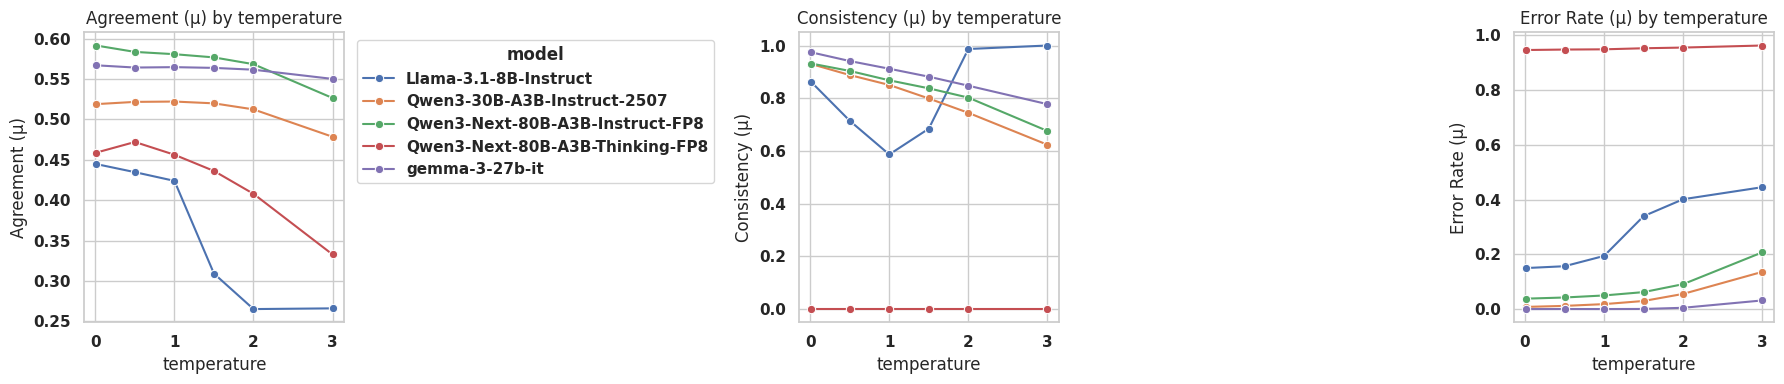

Saved: output/causal_analysis/temperature_metric_trends_by_model.png


In [26]:
display(COLUMN_MAP)

display(combined_df[ANALYSIS_COLUMNS].head())

descriptive_stats = (
    combined_df.groupby(TREATMENT_SOURCE, observed=True)[METRIC_COLUMNS]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)
display(descriptive_stats)

treatment_counts = combined_df["temperature_bucket"].value_counts().rename_axis("temperature_bucket").to_frame("rows")
display(treatment_counts)

balance_summary, balance_detail = compute_balance_table(combined_df)
print("Balance summary by covariate family (absolute SMD):")
display(balance_summary.round(4))

print("Largest individual imbalances:")
display(balance_detail.head(10).round(4))

temp_by_model = (
    combined_df.groupby([TREATMENT_SOURCE, "model"], observed=True)[METRIC_COLUMNS]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for ax, outcome_col in zip(axes, METRIC_COLUMNS):
    sns.lineplot(
        data=temp_by_model,
        x=TREATMENT_SOURCE,
        y=outcome_col,
        hue="model",
        marker="o",
        ax=ax,
    )
    ax.set_title(f"{outcome_col} by temperature")
    ax.set_xlabel("temperature")
    ax.set_ylabel(outcome_col)
    if ax is not axes[0]:
        ax.get_legend().remove()

axes[0].legend(title="model", bbox_to_anchor=(1.02, 1.0), loc="upper left")
plt.tight_layout()
trend_path = FIG_DIR / "temperature_metric_trends_by_model.png"
fig.savefig(trend_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", trend_path)

## 1. Introduction
Primary causal question: what is the average treatment effect of moving from the low-temperature regime to the high-temperature regime on each metric?

## 3. Identification and ATE Estimation
We assume conditional unconfoundedness after adjusting for `question_id`, `judge_type`, `prompt_variant`, and `model`, with `judge_type`, `prompt_variant`, and `model` also treated as moderators in subgroup analysis.

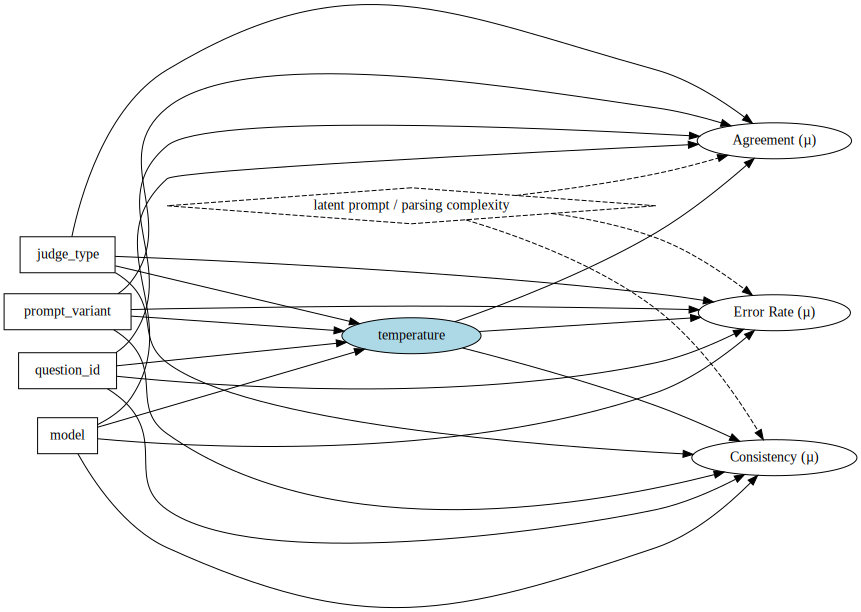

Saved: output/causal_analysis/temperature_causal_dag.png
[AIPW] Agreement (µ): fitting fold 1/3
[AIPW] Agreement (µ): fitting fold 2/3
[AIPW] Agreement (µ): fitting fold 3/3
[AIPW] Consistency (µ): fitting fold 1/3
[AIPW] Consistency (µ): fitting fold 2/3
[AIPW] Consistency (µ): fitting fold 3/3
[AIPW] Error Rate (µ): fitting fold 1/3
[AIPW] Error Rate (µ): fitting fold 2/3
[AIPW] Error Rate (µ): fitting fold 3/3


,Outcome,N,Outcome mean (control),Outcome mean (treated),ATE,SE,CI Low,CI High,ATE (95% CI)
0,Agreement (µ),79870,0.519630,0.468808,-0.052058,0.002246,-0.056461,-0.047655,"-0.0521 [-0.0565, -0.0477]"
1,Consistency (µ),86598,0.689251,0.627243,-0.063974,0.001599,-0.067108,-0.060841,"-0.0640 [-0.0671, -0.0608]"
2,Error Rate (µ),90000,0.234109,0.311485,0.077368,0.000971,0.075464,0.079272,"0.0774 [0.0755, 0.0793]"


Saved: output/causal_analysis/aipw_ate_results.csv
Moderator summary: judge_type


,Outcome,Moderator,Level,N,ATE,CI Low,CI High,ATE (95% CI)
0,Agreement (µ),judge_type,reference_guided,25522,-0.072192,-0.081783,-0.062601,"-0.0722 [-0.0818, -0.0626]"
1,Agreement (µ),judge_type,pairwise,27764,-0.047930,-0.057009,-0.038850,"-0.0479 [-0.0570, -0.0389]"
2,Agreement (µ),judge_type,single_answer,26584,-0.039976,-0.049559,-0.030394,"-0.0400 [-0.0496, -0.0304]"
3,Consistency (µ),judge_type,single_answer,27070,-0.095636,-0.103440,-0.087832,"-0.0956 [-0.1034, -0.0878]"
4,Consistency (µ),judge_type,pairwise,29812,-0.060138,-0.064663,-0.055613,"-0.0601 [-0.0647, -0.0556]"
5,Consistency (µ),judge_type,reference_guided,29716,-0.036049,-0.041396,-0.030701,"-0.0360 [-0.0414, -0.0307]"
6,Error Rate (µ),judge_type,reference_guided,30000,0.028140,0.024781,0.031499,"0.0281 [0.0248, 0.0315]"
7,Error Rate (µ),judge_type,pairwise,30000,0.048392,0.045425,0.051358,"0.0484 [0.0454, 0.0514]"
8,Error Rate (µ),judge_type,single_answer,30000,0.152207,0.147867,0.156547,"0.1522 [0.1479, 0.1565]"


Saved: output/causal_analysis/moderator_ate_judge_type.csv
Moderator summary: prompt_variant


,Outcome,Moderator,Level,N,ATE,CI Low,CI High,ATE (95% CI)
0,Agreement (µ),prompt_variant,cot,38768,-0.064387,-0.071859,-0.056915,"-0.0644 [-0.0719, -0.0569]"
1,Agreement (µ),prompt_variant,baseline,41102,-0.036423,-0.044134,-0.028713,"-0.0364 [-0.0441, -0.0287]"
2,Consistency (µ),prompt_variant,baseline,43428,-0.073148,-0.077355,-0.068942,"-0.0731 [-0.0774, -0.0689]"
3,Consistency (µ),prompt_variant,cot,43170,-0.052633,-0.057191,-0.048074,"-0.0526 [-0.0572, -0.0481]"
4,Error Rate (µ),prompt_variant,baseline,45000,0.058037,0.055596,0.060478,"0.0580 [0.0556, 0.0605]"
5,Error Rate (µ),prompt_variant,cot,45000,0.096866,0.093532,0.100200,"0.0969 [0.0935, 0.1002]"


Saved: output/causal_analysis/moderator_ate_prompt_variant.csv
Moderator summary: model


,Outcome,Moderator,Level,N,ATE,CI Low,CI High,ATE (95% CI)
0,Agreement (µ),model,Llama-3.1-8B-Instruct,17183,-0.159370,-0.173530,-0.145210,"-0.1594 [-0.1735, -0.1452]"
1,Agreement (µ),model,Qwen3-Next-80B-A3B-Thinking-FP8,8767,-0.061261,-0.083608,-0.038914,"-0.0613 [-0.0836, -0.0389]"
2,Agreement (µ),model,Qwen3-Next-80B-A3B-Instruct-FP8,17929,-0.030619,-0.042880,-0.018358,"-0.0306 [-0.0429, -0.0184]"
3,Agreement (µ),model,Qwen3-30B-A3B-Instruct-2507,17993,-0.011716,-0.024006,0.000574,"-0.0117 [-0.0240, 0.0006]"
4,Agreement (µ),model,gemma-3-27b-it,17998,-0.003029,-0.015782,0.009723,"-0.0030 [-0.0158, 0.0097]"
5,Consistency (µ),model,Qwen3-30B-A3B-Instruct-2507,17982,-0.167746,-0.175224,-0.160268,"-0.1677 [-0.1752, -0.1603]"
6,Consistency (µ),model,Qwen3-Next-80B-A3B-Instruct-FP8,17828,-0.129626,-0.137066,-0.122185,"-0.1296 [-0.1371, -0.1222]"
7,Consistency (µ),model,gemma-3-27b-it,17997,-0.107789,-0.113957,-0.101621,"-0.1078 [-0.1140, -0.1016]"
8,Consistency (µ),model,Qwen3-Next-80B-A3B-Thinking-FP8,18000,0.000000,0.000000,0.000000,"0.0000 [0.0000, 0.0000]"
9,Consistency (µ),model,Llama-3.1-8B-Instruct,14791,0.113936,0.101242,0.126631,"0.1139 [0.1012, 0.1266]"


Saved: output/causal_analysis/moderator_ate_model.csv


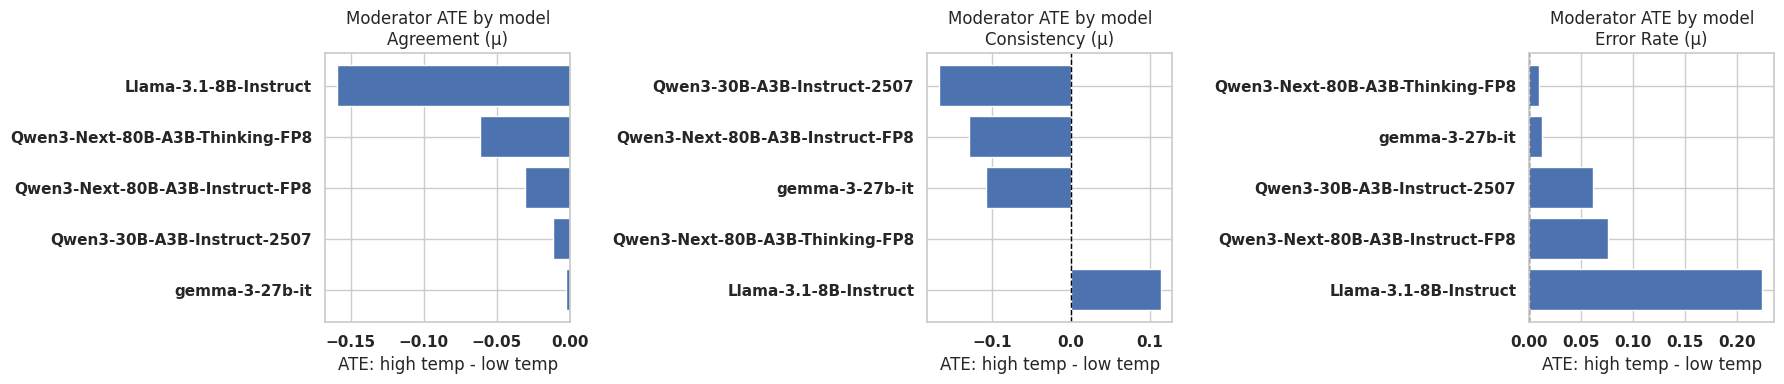

Saved: output/causal_analysis/moderator_ate_by_model.png


In [27]:
display(Markdown("## 1. Introduction\nPrimary causal question: what is the average treatment effect of moving from the low-temperature regime to the high-temperature regime on each metric?"))
display(Markdown("## 3. Identification and ATE Estimation\nWe assume conditional unconfoundedness after adjusting for `question_id`, `judge_type`, `prompt_variant`, and `model`, with `judge_type`, `prompt_variant`, and `model` also treated as moderators in subgroup analysis."))

dag = build_dag()
display(dag)
try:
    dag_path = FIG_DIR / "temperature_causal_dag"
    dag.render(dag_path.as_posix(), format="png", cleanup=True)
    print("Saved:", dag_path.with_suffix(".png"))
except Exception as exc:
    print("DAG render skipped:", repr(exc))

aipw_results = {}
ate_rows = []
for outcome_col in METRIC_COLUMNS:
    result = cross_fitted_aipw(
        combined_df,
        outcome_col=outcome_col,
        n_splits=3,
        random_state=42,
        n_estimators=200,
        display_progress=True,
        progress_prefix="[AIPW] ",
    )
    aipw_results[outcome_col] = result
    ate_rows.append(
        {
            "Outcome": outcome_col,
            "N": result["N"],
            "Outcome mean (control)": result["Outcome mean (control)"],
            "Outcome mean (treated)": result["Outcome mean (treated)"],
            "ATE": result["ATE"],
            "SE": result["SE"],
            "CI Low": result["CI Low"],
            "CI High": result["CI High"],
            "ATE (95% CI)": result["ATE (95% CI)"],
        }
    )

ate_table = pd.DataFrame(ate_rows)
display(ate_table)
ate_path = FIG_DIR / "aipw_ate_results.csv"
ate_table.to_csv(ate_path, index=False)
print("Saved:", ate_path)

moderator_results = {}
for moderator in MODERATOR_COLUMNS:
    frames = []
    for outcome_col in METRIC_COLUMNS:
        subgroup_table = subgroup_ate(combined_df, outcome_col=outcome_col, subgroup_col=moderator)
        frames.append(subgroup_table)
    moderator_results[moderator] = pd.concat(frames, ignore_index=True)
    print(f"Moderator summary: {moderator}")
    display(moderator_results[moderator].head(12))
    moderator_path = FIG_DIR / f"moderator_ate_{moderator}.csv"
    moderator_results[moderator].to_csv(moderator_path, index=False)
    print("Saved:", moderator_path)

model_moderator_plot = moderator_results["model"].copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
for ax, outcome_col in zip(axes, METRIC_COLUMNS):
    plot_df = model_moderator_plot.loc[model_moderator_plot["Outcome"] == outcome_col].copy()
    plot_df = plot_df.sort_values("ATE", ascending=False)
    ax.barh(plot_df["Level"], plot_df["ATE"], color="#4c72b0")
    ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Moderator ATE by model\n{outcome_col}")
    ax.set_xlabel("ATE: high temp - low temp")

plt.tight_layout()
moderator_fig_path = FIG_DIR / "moderator_ate_by_model.png"
fig.savefig(moderator_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", moderator_fig_path)

## 4. Shapley-based Feature Attribution
True causal SHAP is not directly available in this environment, so we report DAG-aware grouped SHAP on the nuisance models used by the doubly robust pipeline.

[SHAP] fitting nuisance models for Agreement (µ)
[SHAP] fitting nuisance models for Consistency (µ)
[SHAP] fitting nuisance models for Error Rate (µ)
Outcome-model grouped SHAP:


,group,mean_abs_shap,title,Outcome
0,question_id,0.214999,Agreement (µ),Agreement (µ)
1,model,0.084544,Agreement (µ),Agreement (µ)
2,judge_type,0.053931,Agreement (µ),Agreement (µ)
3,temperature,0.034248,Agreement (µ),Agreement (µ)
4,prompt_variant,0.011110,Agreement (µ),Agreement (µ)
5,model,0.274685,Consistency (µ),Consistency (µ)
6,question_id,0.048328,Consistency (µ),Consistency (µ)
7,judge_type,0.037553,Consistency (µ),Consistency (µ)
8,temperature,0.037497,Consistency (µ),Consistency (µ)
9,prompt_variant,0.024072,Consistency (µ),Consistency (µ)


Propensity-model grouped SHAP:


,group,mean_abs_shap,title,Outcome
0,model,0.050988,Agreement (µ),Agreement (µ)
1,question_id,0.039716,Agreement (µ),Agreement (µ)
2,judge_type,0.024600,Agreement (µ),Agreement (µ)
3,prompt_variant,0.009116,Agreement (µ),Agreement (µ)
4,model,0.152060,Consistency (µ),Consistency (µ)
5,judge_type,0.148787,Consistency (µ),Consistency (µ)
6,question_id,0.036051,Consistency (µ),Consistency (µ)
7,prompt_variant,0.011410,Consistency (µ),Consistency (µ)
8,judge_type,0.000000,Error Rate (µ),Error Rate (µ)
9,model,0.000000,Error Rate (µ),Error Rate (µ)


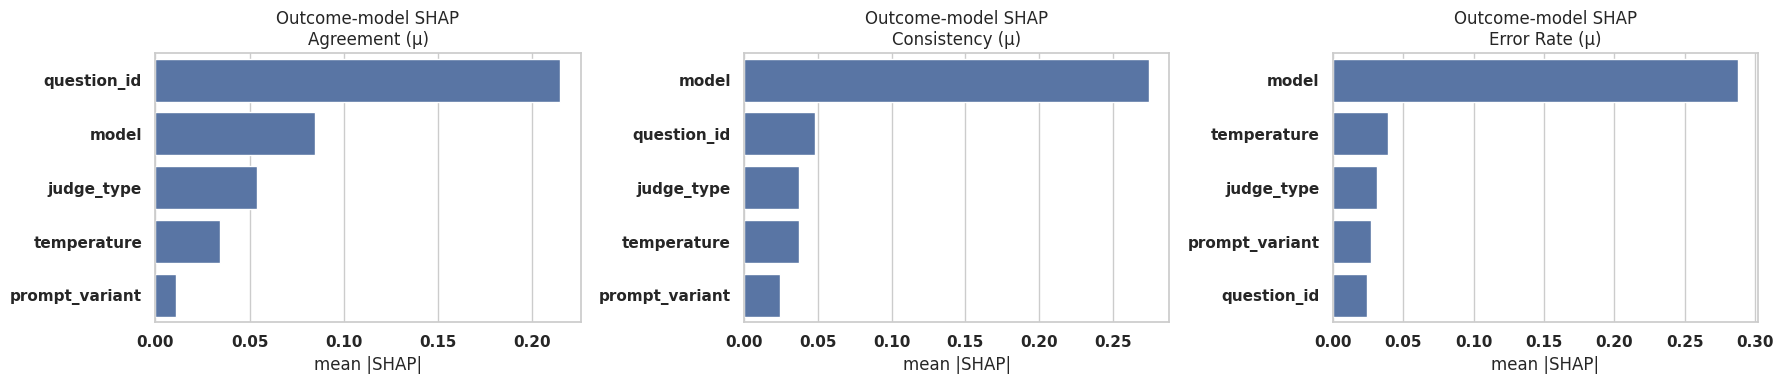

Saved: output/causal_analysis/outcome_model_grouped_shap.png


## 5. Robustness Checks

[Placebo] Agreement (µ): placebo permutation 1/10
[Placebo] Agreement (µ): placebo permutation 2/10
[Placebo] Agreement (µ): placebo permutation 3/10
[Placebo] Agreement (µ): placebo permutation 4/10
[Placebo] Agreement (µ): placebo permutation 5/10
[Placebo] Agreement (µ): placebo permutation 6/10
[Placebo] Agreement (µ): placebo permutation 7/10
[Placebo] Agreement (µ): placebo permutation 8/10
[Placebo] Agreement (µ): placebo permutation 9/10
[Placebo] Agreement (µ): placebo permutation 10/10
[Placebo] Consistency (µ): placebo permutation 1/10
[Placebo] Consistency (µ): placebo permutation 2/10
[Placebo] Consistency (µ): placebo permutation 3/10
[Placebo] Consistency (µ): placebo permutation 4/10
[Placebo] Consistency (µ): placebo permutation 5/10
[Placebo] Consistency (µ): placebo permutation 6/10
[Placebo] Consistency (µ): placebo permutation 7/10
[Placebo] Consistency (µ): placebo permutation 8/10
[Placebo] Consistency (µ): placebo permutation 9/10
[Placebo] Consistency (µ): plac

,Outcome,Observed ATE,Placebo mean,Placebo std,Permutation p-value
0,Agreement (µ),-0.050286,0.000845,0.001711,0.090909
1,Consistency (µ),-0.063406,-0.000339,0.001187,0.090909
2,Error Rate (µ),0.077418,-0.000018,0.001167,0.090909


Saved: output/causal_analysis/placebo_permutation_results.csv


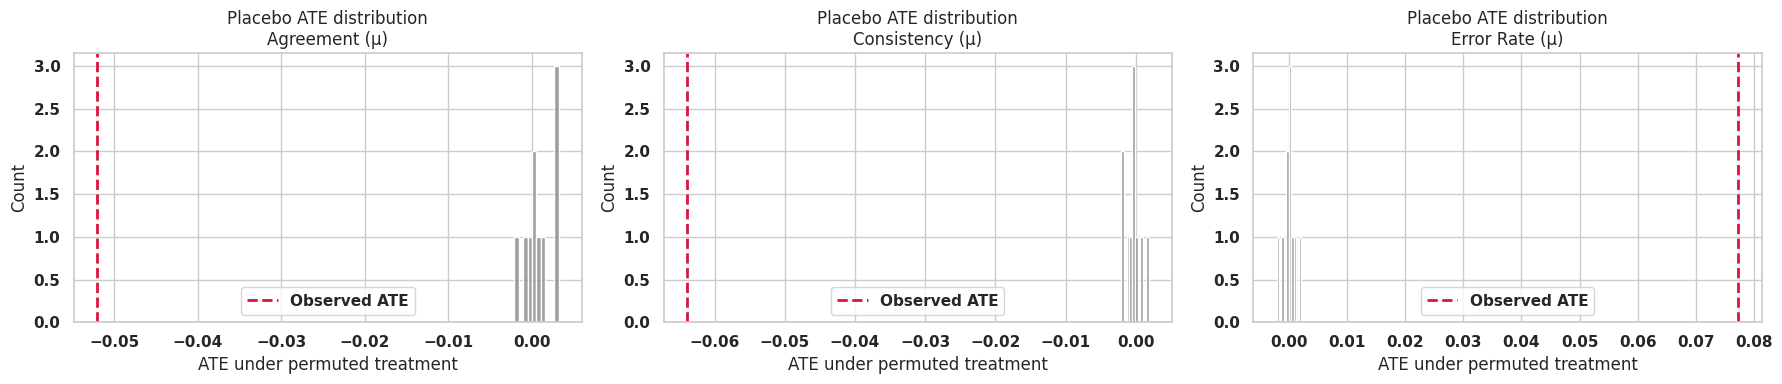

Saved: output/causal_analysis/placebo_permutation_histograms.png


,Cohen's d,Approx RR,E-value,Outcome
0,-0.115361,1.110687,1.461313,Agreement (µ)
1,-0.157148,1.153735,1.574888,Consistency (µ)
2,0.194716,1.193860,1.674943,Error Rate (µ)


Saved: output/causal_analysis/approximate_evalues.csv
[SHAP stability] Agreement (µ): SHAP bootstrap 1/8
[SHAP stability] Agreement (µ): SHAP bootstrap 2/8
[SHAP stability] Agreement (µ): SHAP bootstrap 3/8
[SHAP stability] Agreement (µ): SHAP bootstrap 4/8
[SHAP stability] Agreement (µ): SHAP bootstrap 5/8
[SHAP stability] Agreement (µ): SHAP bootstrap 6/8
[SHAP stability] Agreement (µ): SHAP bootstrap 7/8
[SHAP stability] Agreement (µ): SHAP bootstrap 8/8
[SHAP stability] Consistency (µ): SHAP bootstrap 1/8
[SHAP stability] Consistency (µ): SHAP bootstrap 2/8
[SHAP stability] Consistency (µ): SHAP bootstrap 3/8
[SHAP stability] Consistency (µ): SHAP bootstrap 4/8
[SHAP stability] Consistency (µ): SHAP bootstrap 5/8
[SHAP stability] Consistency (µ): SHAP bootstrap 6/8
[SHAP stability] Consistency (µ): SHAP bootstrap 7/8
[SHAP stability] Consistency (µ): SHAP bootstrap 8/8
[SHAP stability] Error Rate (µ): SHAP bootstrap 1/8
[SHAP stability] Error Rate (µ): SHAP bootstrap 2/8
[SHAP stab

,index,Outcome,group,bootstrap_mean_abs_shap,bootstrap_std_abs_shap
0,3,Agreement (µ),question_id,0.211309,0.001912
1,1,Agreement (µ),model,0.083303,0.002023
2,0,Agreement (µ),judge_type,0.048099,0.001375
3,4,Agreement (µ),temperature,0.033869,0.001351
4,2,Agreement (µ),prompt_variant,0.008555,0.000517
5,1,Consistency (µ),model,0.272956,0.003256
6,3,Consistency (µ),question_id,0.050503,0.000641
7,0,Consistency (µ),judge_type,0.037740,0.001155
8,4,Consistency (µ),temperature,0.036479,0.000616
9,2,Consistency (µ),prompt_variant,0.023762,0.000516


Saved: output/causal_analysis/shap_stability_summary.csv


## 6. Discussion

,Outcome,ATE interpretation,Top SHAP driver,Strongest model moderator,Permutation p-value,Approx E-value
0,Agreement (µ),Moving to high temperature decreases Agreement...,question_id,Llama-3.1-8B-Instruct,0.090909,1.461313
1,Consistency (µ),Moving to high temperature decreases Consisten...,model,Qwen3-30B-A3B-Instruct-2507,0.090909,1.574888
2,Error Rate (µ),Moving to high temperature increases Error Rat...,model,Llama-3.1-8B-Instruct,0.090909,1.674943


Saved: output/causal_analysis/discussion_summary.csv


## Automatically generated discussion
- **Agreement (µ)**: Moving to high temperature decreases Agreement (µ) by -0.0521 on average. Top nuisance-model SHAP driver: `question_id`. Strongest model-level moderator: `Llama-3.1-8B-Instruct`. Permutation p-value = 0.0909; approximate E-value = 1.4613.
- **Consistency (µ)**: Moving to high temperature decreases Consistency (µ) by -0.0640 on average. Top nuisance-model SHAP driver: `model`. Strongest model-level moderator: `Qwen3-30B-A3B-Instruct-2507`. Permutation p-value = 0.0909; approximate E-value = 1.5749.
- **Error Rate (µ)**: Moving to high temperature increases Error Rate (µ) by 0.0774 on average. Top nuisance-model SHAP driver: `model`. Strongest model-level moderator: `Llama-3.1-8B-Instruct`. Permutation p-value = 0.0909; approximate E-value = 1.6749.

In [28]:
display(Markdown("## 4. Shapley-based Feature Attribution\nTrue causal SHAP is not directly available in this environment, so we report DAG-aware grouped SHAP on the nuisance models used by the doubly robust pipeline."))

outcome_feature_groups = {
    TREATMENT_COL: "temperature",
    "question_id": "question_id",
    "judge_type": "judge_type",
    "prompt_variant": "prompt_variant",
    "model": "model",
}
propensity_feature_groups = {key: key for key in COVARIATE_COLUMNS}

outcome_shap_tables = []
propensity_shap_tables = []
for outcome_col in METRIC_COLUMNS:
    print(f"[SHAP] fitting nuisance models for {outcome_col}")
    nuisance_df, outcome_model, propensity_model = fit_global_nuisance_models(combined_df, outcome_col)

    grouped_outcome_shap, _ = grouped_shap_importance(
        outcome_model,
        nuisance_df[[TREATMENT_COL] + COVARIATE_COLUMNS],
        feature_groups=outcome_feature_groups,
        max_rows=3000,
        random_state=42,
        title=outcome_col,
    )
    grouped_outcome_shap["Outcome"] = outcome_col
    outcome_shap_tables.append(grouped_outcome_shap)

    grouped_prop_shap, _ = grouped_shap_importance(
        propensity_model,
        nuisance_df[COVARIATE_COLUMNS],
        feature_groups=propensity_feature_groups,
        max_rows=3000,
        random_state=84,
        title=outcome_col,
    )
    grouped_prop_shap["Outcome"] = outcome_col
    propensity_shap_tables.append(grouped_prop_shap)

outcome_shap_df = pd.concat(outcome_shap_tables, ignore_index=True)
propensity_shap_df = pd.concat(propensity_shap_tables, ignore_index=True)

print("Outcome-model grouped SHAP:")
display(outcome_shap_df)

print("Propensity-model grouped SHAP:")
display(propensity_shap_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=False)
for ax, outcome_col in zip(axes, METRIC_COLUMNS):
    plot_df = outcome_shap_df.loc[outcome_shap_df["Outcome"] == outcome_col].sort_values("mean_abs_shap", ascending=False)
    sns.barplot(data=plot_df, x="mean_abs_shap", y="group", ax=ax, color="#4c72b0")
    ax.set_title(f"Outcome-model SHAP\n{outcome_col}")
    ax.set_xlabel("mean |SHAP|")
    ax.set_ylabel("")

plt.tight_layout()
outcome_shap_path = FIG_DIR / "outcome_model_grouped_shap.png"
fig.savefig(outcome_shap_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", outcome_shap_path)

display(Markdown("## 5. Robustness Checks"))

placebo_results = []
placebo_draw_map = {}
for idx, outcome_col in enumerate(METRIC_COLUMNS):
    placebo = placebo_permutation_test(
        combined_df,
        outcome_col=outcome_col,
        n_perm=10,
        random_state=100 + idx,
        progress_prefix="[Placebo] ",
    )
    placebo_draw_map[outcome_col] = placebo["placebo_draws"]
    placebo_results.append({
        key: value
        for key, value in placebo.items()
        if key != "placebo_draws"
    })

placebo_table = pd.DataFrame(placebo_results)
display(placebo_table)
placebo_path = FIG_DIR / "placebo_permutation_results.csv"
placebo_table.to_csv(placebo_path, index=False)
print("Saved:", placebo_path)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
for ax, outcome_col in zip(axes, METRIC_COLUMNS):
    sns.histplot(placebo_draw_map[outcome_col], bins=10, color="gray", ax=ax)
    ax.axvline(aipw_results[outcome_col]["ATE"], color="crimson", linestyle="--", linewidth=2, label="Observed ATE")
    ax.set_title(f"Placebo ATE distribution\n{outcome_col}")
    ax.set_xlabel("ATE under permuted treatment")
    ax.legend()

plt.tight_layout()
placebo_fig_path = FIG_DIR / "placebo_permutation_histograms.png"
fig.savefig(placebo_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", placebo_fig_path)

evalue_rows = []
for outcome_col in METRIC_COLUMNS:
    metrics = approximate_e_value(combined_df[outcome_col], aipw_results[outcome_col]["ATE"])
    metrics["Outcome"] = outcome_col
    evalue_rows.append(metrics)

evalue_table = pd.DataFrame(evalue_rows)
display(evalue_table)
evalue_path = FIG_DIR / "approximate_evalues.csv"
evalue_table.to_csv(evalue_path, index=False)
print("Saved:", evalue_path)

shap_stability_frames = []
for outcome_col in METRIC_COLUMNS:
    stability = shap_stability(
        combined_df,
        outcome_col=outcome_col,
        feature_cols=[TREATMENT_COL] + COVARIATE_COLUMNS,
        feature_groups=outcome_feature_groups,
        n_boot=8,
        max_rows=2500,
        random_state=300,
        progress_prefix="[SHAP stability] ",
    )
    shap_stability_frames.append(stability)

shap_stability_df = pd.concat(shap_stability_frames, ignore_index=True)
display(shap_stability_df)
stability_path = FIG_DIR / "shap_stability_summary.csv"
shap_stability_df.to_csv(stability_path, index=False)
print("Saved:", stability_path)

display(Markdown("## 6. Discussion"))

discussion_rows = []
for outcome_col in METRIC_COLUMNS:
    ate_value = aipw_results[outcome_col]["ATE"]
    direction = "increases" if ate_value >= 0 else "decreases"
    top_driver = outcome_shap_df.loc[outcome_shap_df["Outcome"] == outcome_col].iloc[0]["group"]
    top_model_level = (
        moderator_results["model"]
        .loc[moderator_results["model"]["Outcome"] == outcome_col]
        .sort_values("ATE", key=lambda s: s.abs(), ascending=False)
        .iloc[0]["Level"]
    )
    discussion_rows.append(
        {
            "Outcome": outcome_col,
            "ATE interpretation": f"Moving to high temperature {direction} {outcome_col} by {ate_value:.4f} on average.",
            "Top SHAP driver": top_driver,
            "Strongest model moderator": top_model_level,
            "Permutation p-value": float(placebo_table.loc[placebo_table["Outcome"] == outcome_col, "Permutation p-value"].iloc[0]),
            "Approx E-value": float(evalue_table.loc[evalue_table["Outcome"] == outcome_col, "E-value"].iloc[0]),
        }
    )

discussion_table = pd.DataFrame(discussion_rows)
display(discussion_table)
discussion_path = FIG_DIR / "discussion_summary.csv"
discussion_table.to_csv(discussion_path, index=False)
print("Saved:", discussion_path)

summary_lines = ["## Automatically generated discussion"]
for row in discussion_table.itertuples(index=False):
    summary_lines.append(
        f"- **{row.Outcome}**: {row._1 if False else row[1]} Top nuisance-model SHAP driver: `{row[2]}`. Strongest model-level moderator: `{row[3]}`. Permutation p-value = {row[4]:.4f}; approximate E-value = {row[5]:.4f}."
    )
display(Markdown("\n".join(summary_lines)))

## Extra: SHAP Beeswarm

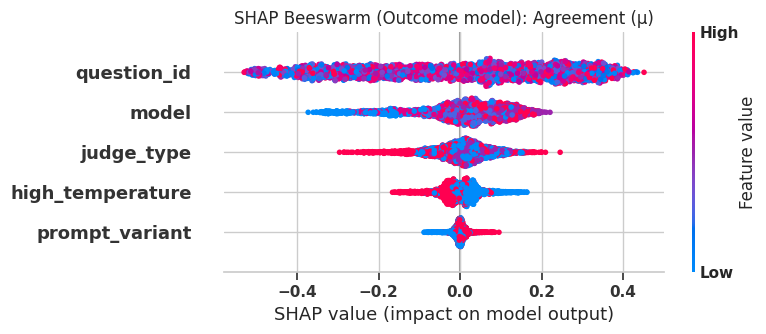

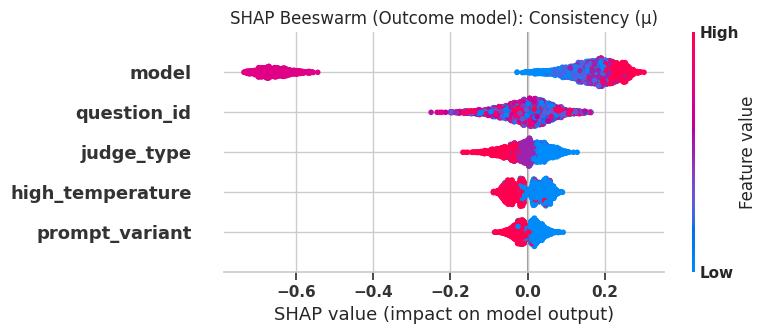

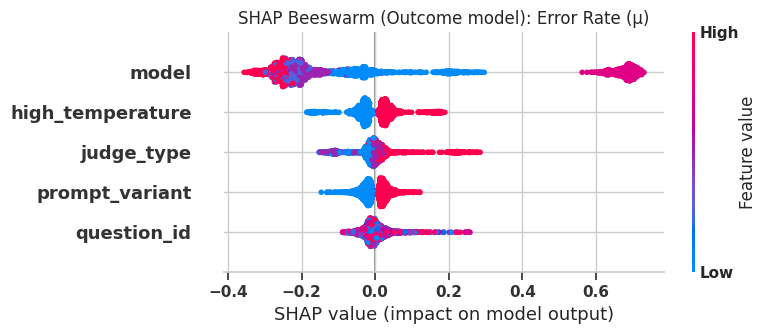

Saved beeswarm plots:
- output/causal_analysis/outcome_model_shap_beeswarm_Agreement_mu.png
- output/causal_analysis/outcome_model_shap_beeswarm_Consistency_mu.png
- output/causal_analysis/outcome_model_shap_beeswarm_Error_Rate_mu.png


In [29]:
display(Markdown("## Extra: SHAP Beeswarm"))

beeswarm_paths = []
beeswarm_feature_cols = [TREATMENT_COL] + COVARIATE_COLUMNS

for outcome_col in METRIC_COLUMNS:
    nuisance_df, outcome_model, _ = fit_global_nuisance_models(combined_df, outcome_col)

    model_feature_df = nuisance_df[beeswarm_feature_cols].copy()
    plot_feature_df = model_feature_df.copy()

    for col in plot_feature_df.columns:
        if str(plot_feature_df[col].dtype) in {"category", "object"}:
            plot_feature_df[col] = plot_feature_df[col].astype("category").cat.codes

    sample_idx = plot_feature_df.sample(min(len(plot_feature_df), 3000), random_state=2026).index
    sample_model_df = model_feature_df.loc[sample_idx]
    sample_plot_df = plot_feature_df.loc[sample_idx]

    explainer = shap.TreeExplainer(outcome_model)
    explanation = explainer(sample_model_df)
    values = np.asarray(explanation.values)
    base_values = np.asarray(explanation.base_values)

    beeswarm_exp = shap.Explanation(
        values=values,
        base_values=base_values,
        data=sample_plot_df.to_numpy(),
        feature_names=list(sample_plot_df.columns),
    )

    plt.figure(figsize=(8, 5))
    shap.plots.beeswarm(beeswarm_exp, max_display=12, show=False)
    plt.title(f"SHAP Beeswarm (Outcome model): {outcome_col}")
    plt.tight_layout()

    safe_name = (
        outcome_col
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("µ", "mu")
        .replace("/", "_")
    )
    beeswarm_path = FIG_DIR / f"outcome_model_shap_beeswarm_{safe_name}.png"
    plt.savefig(beeswarm_path, dpi=220, bbox_inches="tight")
    plt.show()
    beeswarm_paths.append(beeswarm_path)

print("Saved beeswarm plots:")
for p in beeswarm_paths:
    print("-", p)